# SHQ Analysis Program 0 - Clean up Dynamometer files to .csv
Updated 04/17/2026

------------------
## Cell 1 - Imports
Import the necessary packages to run the program. 

In [26]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from tkinter import Tk
import re 
from tkinter.filedialog import askdirectory

print(f'{datetime.now()} - Imports OK')

# Also defining custom plot theme in this code block
custom_theme = {"axes.spines.right": False, 
                "axes.spines.top": False,
                "axes.titlelocation": "left", 
                "axes.titley": 1,
                "font.weight":"bold", 
                "axes.titlesize": "x-large", 
                "axes.labelsize": "x-large",
                "axes.titleweight": "bold", 
                "axes.labelweight": 'bold'}

plt.rcParams.update({
    **custom_theme,
    'figure.facecolor': 'white',  # transparent background for plots
    'axes.labelcolor': 'black',   # White axes labels
    'axes.edgecolor': 'black',    # White axes edge color
    'xtick.color': 'black',       # White x-axis tick labels
    'ytick.color': 'black',       # white y-axis tick labels
    "axes.titlecolor": "black"    # white title label
})

2026-04-17 09:12:35.219798 - Imports OK


-------
## Cell 2 - Define Functions
Define the custom functions to use. 

In [ ]:
### Read a .txt file with either a "," or "\t" as the delimeter. 
def read_txt_auto_delim(file_path):
    try:
        return pd.read_csv(file_path, sep = None, engine = 'python')
    except pd.errors.ParserError:
        try: 
            return pd.read_csv(file_path, sep = ',')
        except pd.errors.ParserError:

            return pd.read_csv(file_path, sep = "\t")

# Helper function to choose the folder in which the data files are stored.
def pick_directory(prompt="Select Participant's Data Folder"):
    root = Tk()
    root.withdraw()
    root.attributes('-topmost', True)
    root.update()
    folder = askdirectory(title=prompt, parent = root)
    root.destroy()
    return folder

def clean_filename(file_name):
    name, ext = os.path.splitext(file_name)
    name = re.sub(r'(?i)^SHQ_?\d+_?', '', name)
    return name + ext

-------
## Cell 3 - Choose the primary data folder
This should be the participant's main folder (e.g., SHQ001, SHQ003, etc.). With subfolders of "Dynamometer Data" that has the .txt files in it. "Full Data" that is where the new Excel .csv files will be saved to. And the "OpenCap_sessionID" folder for that specific participant. This is also where you would start to move to the next participant. 

In [71]:
# Choose the primary data folder
primary_folder = pick_directory() 
dirs = os.listdir(primary_folder)

print(f'Folder is: {primary_folder}. With the following subfolders...')
for d in dirs:
    print(f'      - {d}')

Folder is: E:/Research/0-Mentoring/MoosbruggerJ/SHQ/Data Collection/SHQ022. With the following subfolders...
      - Dynamometer Data
      - Full Data
      - OpenCapData_28e03158-87d4-42fc-a992-4dd667ef290a


-----------
## Cell 4 - Primary Analysis
This will read the .txt file in, determine what delimeter was utilized, plot the .txt file for sanity's check, and move the new .csv file to "Full Data". 


Found: E:/Research/0-Mentoring/MoosbruggerJ/SHQ/Data Collection/SHQ022\Dynamometer Data
      Processing: SHQ022_LEFT_180deg.txt
      Processing: SHQ022_LEFT_60deg.txt
      Processing: SHQ022_LEFT_KE1.txt
      Processing: SHQ022_LEFT_KE2.txt
      Processing: SHQ022_LEFT_KE3.txt
      Processing: SHQ022_LEFT_KF1.txt
      Processing: SHQ022_LEFT_KF2.txt
      Processing: SHQ022_LEFT_KF3.txt
      Processing: SHQ022_RIGHT_180deg.txt
      Processing: SHQ022_RIGHT_60deg.txt
      Processing: SHQ022_RIGHT_KE1.txt
      Processing: SHQ022_RIGHT_KE2.txt
      Processing: SHQ022_RIGHT_KE3.txt
      Processing: SHQ022_RIGHT_KF1.txt
      Processing: SHQ022_RIGHT_KF2.txt
      Processing: SHQ022_RIGHT_KF3.txt

Done, move on to next participant's data.


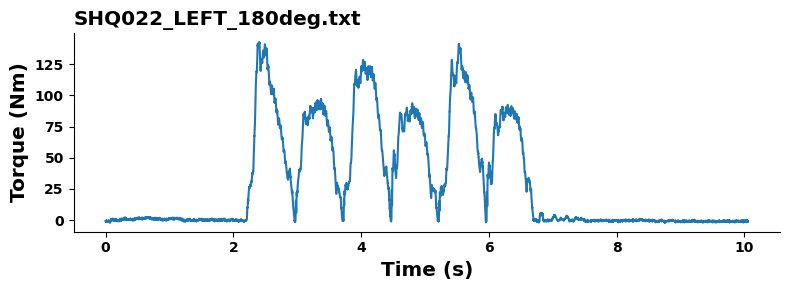

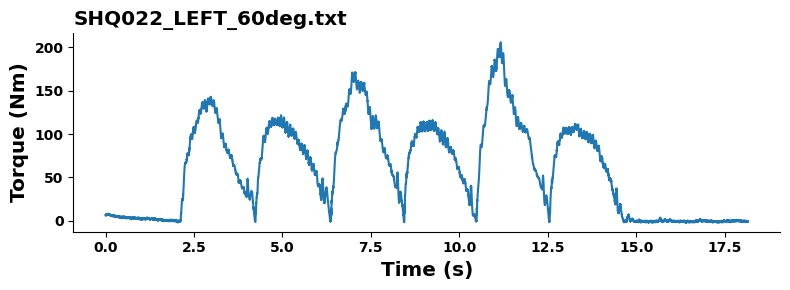

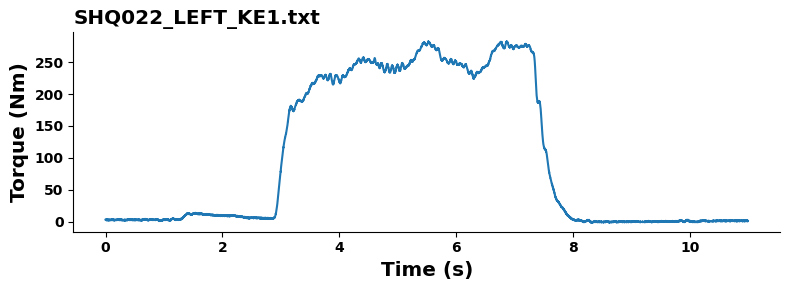

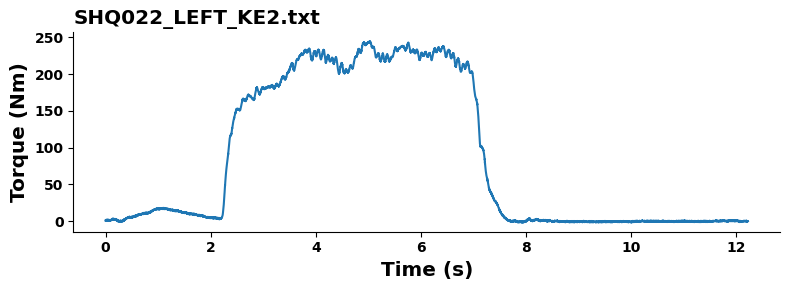

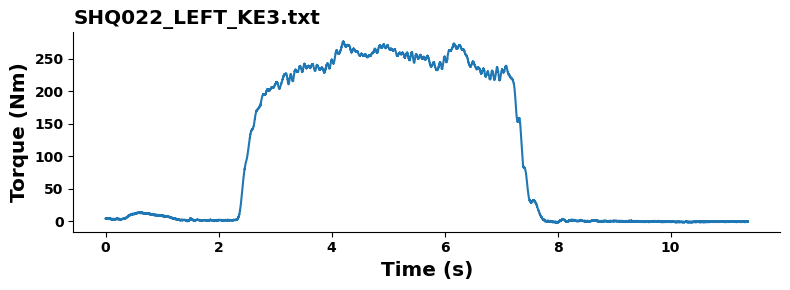

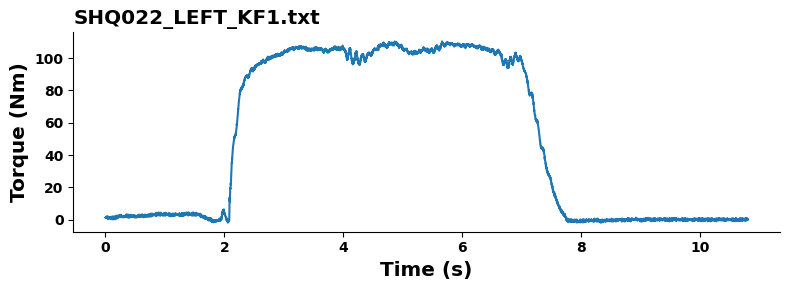

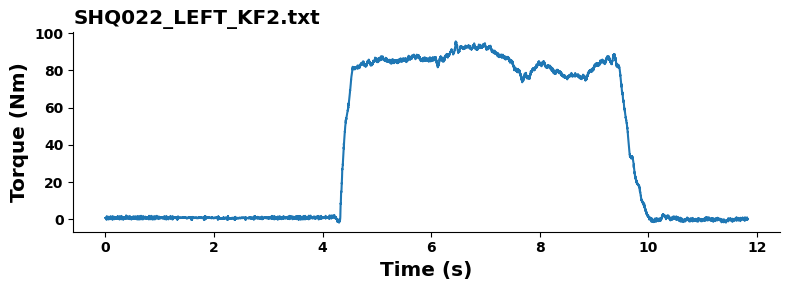

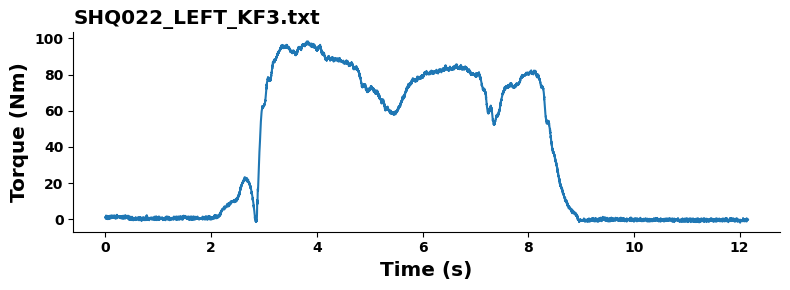

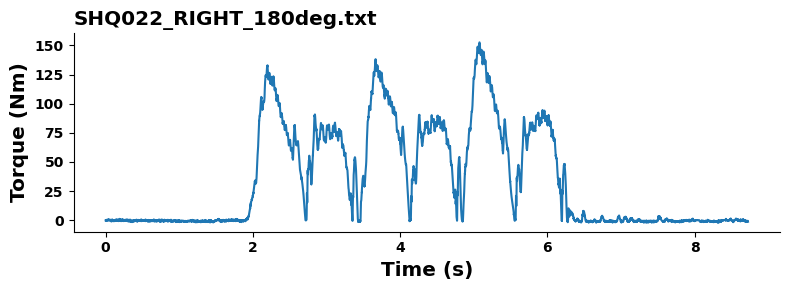

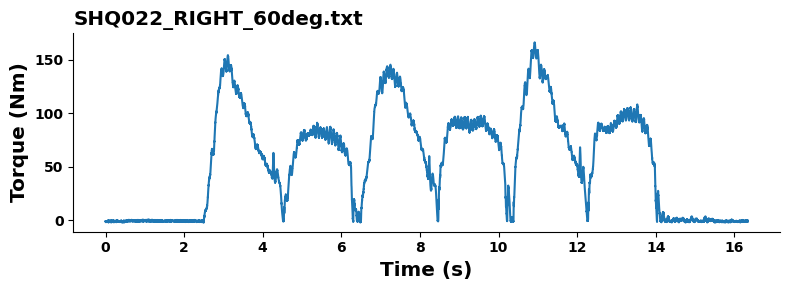

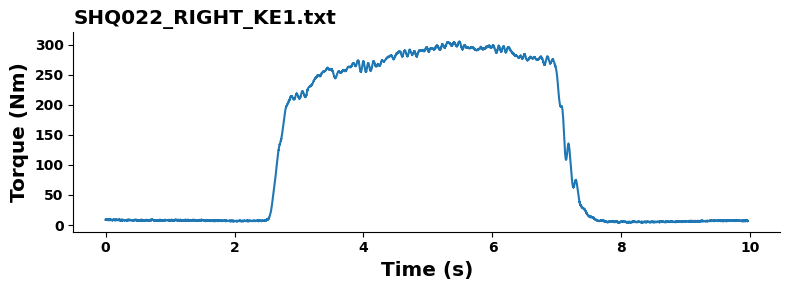

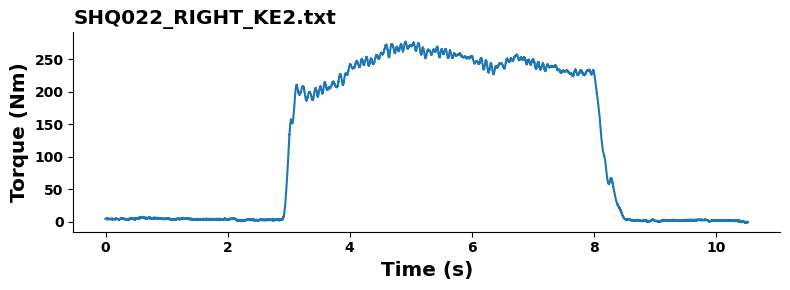

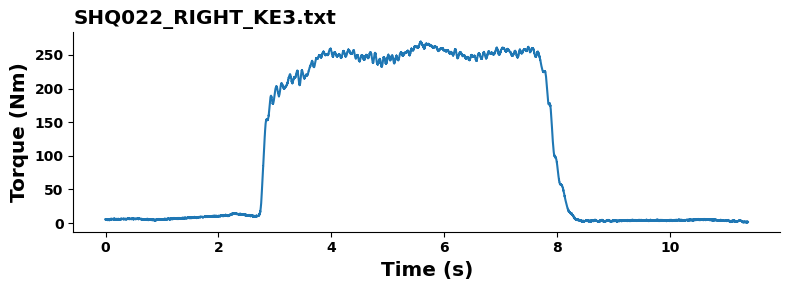

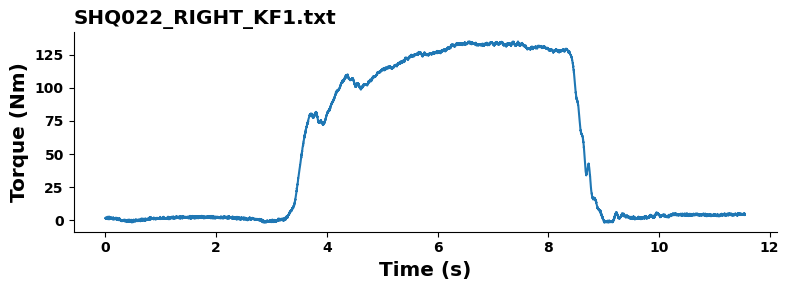

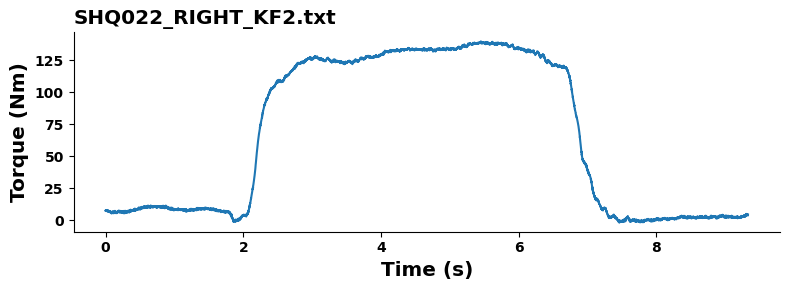

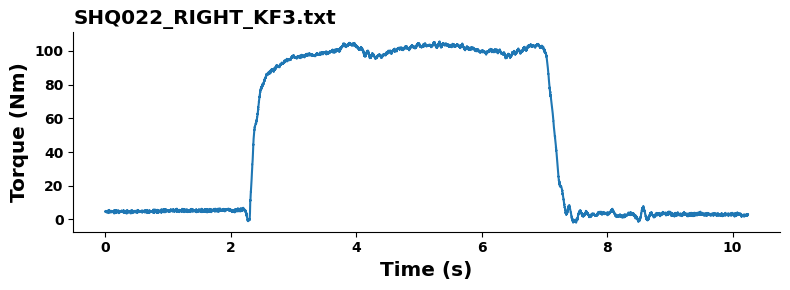

In [72]:
sf = 2000

for root, dirs, files in os.walk(primary_folder):   
    if os.path.basename(root) == "Dynamometer Data":
        print(f'\nFound: {root}')
        #  Get primary subject folder (the top folder) so it is SHQ001 etc.
        subject_folder = os.path.dirname(root)
        # Create / define "Full Data" folder inside subject folder
        full_data_folder = os.path.join(subject_folder, "Full Data")
        # It likely already exists
        os.makedirs(full_data_folder, exist_ok=True)
        for file in files:
            if file.endswith('.txt'):
                txt_path = os.path.join(root, file)
                print(f'      Processing: {file}')
                # Read file
                df = read_txt_auto_delim(txt_path)
                df = df.iloc[:,0:3]
                df.columns = ['volt1', 'volt2', 'Torque']
                # Define time columns
                n_samples = len(df)
                trial_time = n_samples / sf
                time_s = np.linspace(start = 0, stop = trial_time, num = n_samples)               
                # Plot the data
                plt.figure(figsize=(8,3))
                torque = df['Torque']
                plt.title(file)
                plt.plot(time_s, torque)
                plt.xlabel('Time (s)')
                plt.ylabel('Torque (Nm)')
                plt.tight_layout()
                # Save to "Full Data" folder
                clean_name = clean_filename(file)
                csv_name = clean_name.replace('.txt', '.csv')
                csv_path = os.path.join(full_data_folder, csv_name)              
                df.to_csv(csv_path, index=False)

print("\nDone, move on to next participant's data.")